# FIE463 - Individual Assignment

## Optimal savings and portfolio choice

In [1]:
# Preparations
# Modules
import numpy as np
import matplotlib.pyplot as plt

# Define default parameters
beta = .9                               # Discount factor
gamma = 4                               # Absolute risk aversion
sigma_sq = .16**2                       # Variance of risky return shock
mu = .04                                # Expected excess return
w = 1                                   # Initial wealth
rf = 1                                  # Risk-free gross return

sigma = np.sqrt(sigma_sq)               # Sigma from root of sigma_sq (Variance)

# Distribution for risky return
probs = np.array((1/6, 2/3, 1/6))          # Probabilities of eta
etas = np.array((-3**.5, 0, 3**.5))      # Values of eta (shock representing uncertainty)

exp_eta = etas @ probs

### Task 1

In [2]:
# Verify that discretized risky return approximates the true mean and variance of the underlying normal distribution well
R = rf + mu + sigma * etas               # Risky return (vector)
er = rf + mu + sigma * exp_eta          # Expected gross risky return

var = probs @ (R - er)**2                 # Variance of the risky return
std = np.sqrt(var)                       # Standard deviation of the risky return

eR_prem = er - rf                       # Expected risk premium
sharpe = eR_prem / std                    # Sharpe-ratio

# Comparisons
print(f'True mu: {mu} vs Calculated: {eR_prem:.2f}')
print(f'True variance: {var} vs Calculated: {std}')

True mu: 0.04 vs Calculated: 0.04
True variance: 0.0256 vs Calculated: 0.16


Values of expected excess return and variance for the discretized risky return are equal to those of the given parameters. The discretized risky return approximates the true mean and variance of the underlying normal distribution well.

### Task 2

In [3]:
def util(c, gamma):
    '''
    Return the flow utility of consumption for a given risk aversion
    '''
    u = -np.exp(-gamma * c)

    return u

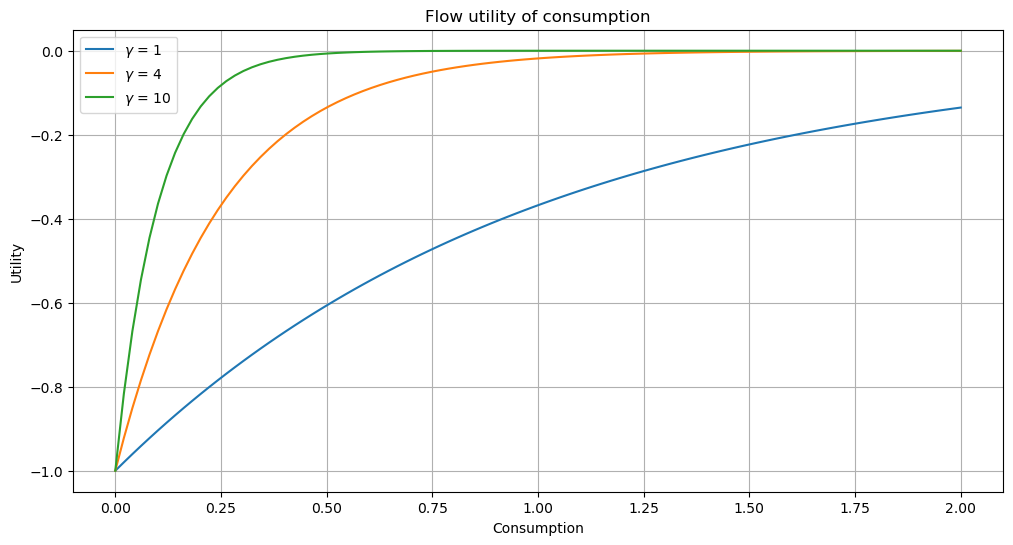

In [4]:
# Intialize parameters
c = np.linspace(0, 2, 100)
gammas = np.array((1, 4, 10))

# Intialize plot
plt.figure(figsize=(12,6))
plt.title('Flow utility of consumption')
plt.xlabel('Consumption')
plt.ylabel('Utility')
plt.grid()

# Loop over array of gammas to plot three separate curves
for g in gammas:
    u = util(c, g)
    plt.plot(c, u, label=fr'$\gamma$ = {g}')


# Display plot
_ = plt.legend()

### Task 3

In [152]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - s
    
    # Risky returns
    R = rf + mu + sigma * etas

    # Handle arrays (Reshaping makes dimensions match for calculation of period 2 consumption)
    if isinstance(alpha, np.ndarray) or isinstance(s, np.ndarray):
        if isinstance(alpha, np.ndarray):
            alpha = alpha.reshape(1, -1, 1)

        if isinstance(s, np.ndarray):
            s = s.reshape(-1, 1, 1)

        R = R.reshape(1, 1, -1)

    else:
        pass

    # Period 2 consumption
    c2 = R * alpha * s + rf * (1 - alpha) * s
    
    # Period 1 utility
    u1 = util(c1, gamma)

    # Period 2 utilities (vector)
    u2 = util(c2, gamma)

    # Period 2 expected utility
    eu2 =  u2 @ probs

    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

In [ ]:
# Debug print statements
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - s
    
    # Risky returns
    R = rf + mu + sigma * etas

    # Handle arrays (Reshaping makes dimensions match for calculation of period 2 consumption)
    if isinstance(alpha, np.ndarray) and isinstance(s, np.ndarray):
        # Both are arrays - need 3D
        s = s.reshape(-1, 1, 1)
        alpha = alpha.reshape(1, -1, 1)
        R = R.reshape(1, 1, -1)
        print(s.shape, alpha.shape, R.shape)
    elif isinstance(alpha, np.ndarray):
        # Only alpha is array - need 2D
        alpha = alpha.reshape(1, -1)
        R = R.reshape(1, -1)
    elif isinstance(s, np.ndarray):
        # Only s is array - need 2D
        s = s.reshape(-1, 1)
        R = R.reshape(1, -1)

    # Period 2 consumption
    c2 = R * alpha * s + rf * (1 - alpha) * s
    
    # Period 1 utility
    u1 = util(c1, gamma).reshape(-1,1,1)
    print(u1.shape)
    # Period 2 utilities (vector)
    u2 = util(c2, gamma)
    print(u2.shape)
    # Period 2 expected utility
    eu2 =  u2 @ probs
    print(eu2)
    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

In [157]:
# Test (DELETE LATER)
expected_util(s=.5, alpha=.5)

np.float64(-0.253868665109095)

In [180]:
s = np.array((.3, .5)).reshape(-1,1,1)
alpha = np.array((.2, .5, .8)).reshape(1,-1,1)
R = np.array((.88, 1.04, 1.20)).reshape(1,1,-1)



c2 = R * alpha * s + (1 - alpha) * s
c2

array([[[0.2928, 0.3024, 0.312 ],
        [0.282 , 0.306 , 0.33  ],
        [0.2712, 0.3096, 0.348 ]],

       [[0.488 , 0.504 , 0.52  ],
        [0.47  , 0.51  , 0.55  ],
        [0.452 , 0.516 , 0.58  ]]])

In [197]:
# Test array (DELETE LATER)
# s = np.array((0, .5, 1))
# alpha = np.array((0, .5, 1))
# s = .4
# alpha = .4
s = np.linspace(.1, w - .1, 2)
alpha = np.linspace(0, 1, 3)
expected_util(s, alpha)

(2, 1, 1) (1, 3, 1) (1, 1, 3)
(2, 1, 1)
(2, 3, 3)
[[-0.67032005 -0.66531944 -0.66103268]
 [-0.02732372 -0.02650206 -0.0279206 ]]


array([[[-0.63061176, -0.62611121, -0.62225313],
        [-0.05191507, -0.05117558, -0.05245226]],

       [[-1.27360809, -1.26910754, -1.26524946],
        [-0.6949114 , -0.6941719 , -0.69544859]]])

In [ ]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - s

    # Period 1 utility
    u1 = util(c1, gamma)
    
    # Risky returns
    R = rf + mu + sigma * etas

    # Handle arrays (Reshaping makes dimensions match for calculation of period 2 consumption)
    if isinstance(alpha, np.ndarray) and isinstance(s, np.ndarray):
        # Both are arrays - need 3D
        s = s.reshape(-1, 1, 1)
        alpha = alpha.reshape(1, -1, 1)
        R = R.reshape(1, 1, -1)
        u1 = u1.reshape(-1,1)
    elif isinstance(alpha, np.ndarray):
        # Only alpha is array - need 2D
        alpha = alpha.reshape(-1, 1)
        R = R.reshape(1, -1)
    elif isinstance(s, np.ndarray):
        # Only s is array - need 2D
        s = s.reshape(-1, 1)
        R = R.reshape(1, -1)
        # u1 = u1.reshape(-1,1)
    # Period 2 consumption
    c2 = R * alpha * s + rf * (1 - alpha) * s
    
    # Period 2 utilities (vector)
    u2 = util(c2, gamma)
    
    # Period 2 expected utility
    eu2 = np.sum(u2 * probs, axis=-1)
    
    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

In [281]:
s = .5
alpha = .5
expected_util(s, alpha)

np.float64(-0.253868665109095)

In [282]:
s = .5
alpha = np.array((0, .5))
expected_util(s, alpha)

array([-0.25713704, -0.25386867])

In [284]:
s = np.array((0, .5))
alpha = np.array((0, .5, 1))
expected_util(s, alpha)

array([[-0.91831564, -0.91831564, -0.91831564],
       [-0.25713704, -0.25386867, -0.25367815]])

### Task 4

In [146]:
alphas = np.array((0, .5, 1))

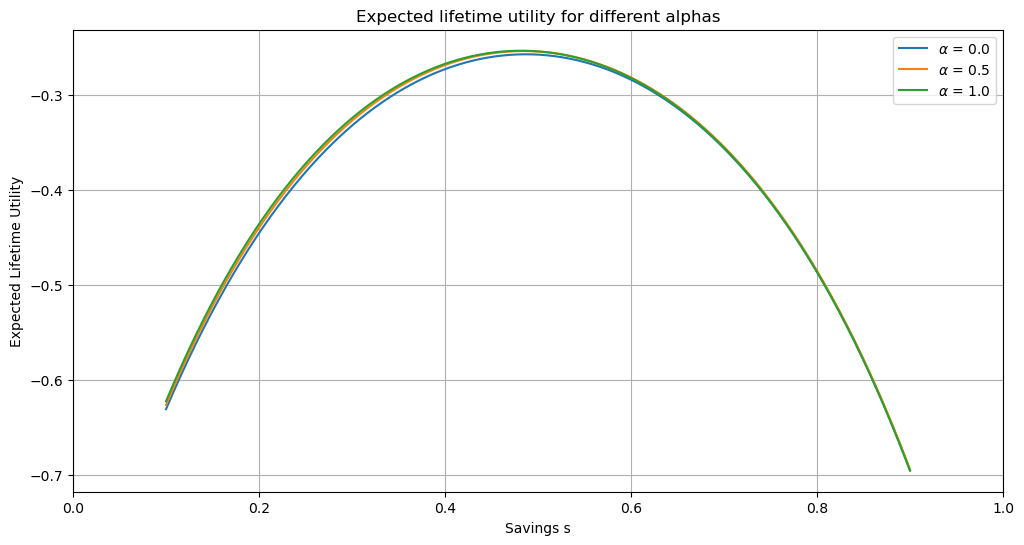

In [285]:
# Initialize parameters s and alpha
alphas = np.array((0, .5, 1))
s = np.linspace(.1, w - .1, 200)

# Initialize plot
plt.figure(figsize=(12,6))
plt.title('Expected lifetime utility for different alphas')
plt.xlabel('Savings s')
plt.ylabel('Expected Lifetime Utility')
plt.xlim((0,1))
plt.grid()

# Loop over alphas to plot
for a in alphas:
    eu_life = expected_util(s=s, alpha=a)
    plt.plot(s, eu_life.flatten(), label=fr'$\alpha$ = {a}')

_ = plt.legend()

The graph indicates that the optimal allocation of consumption between the two periods is about equal, regardless of the level of alpha. The three graphs being almost exactly equal should not be surprising, as the risk-aversion parameter is quite low at this moment.

### Task 5

In [286]:
def find_optimum(beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Find the optimal savings level and risky share to maximize expected utility
    '''
    # Initialize s and alpha as linear spaces
    s = np.linspace(10**-6, w - 10**-6, 1_000)
    alpha = np.linspace(0, 1, 1_000)

    # Calculate expected lifetime utility for all combinations
    eu_life = expected_util(s, alpha)

    # Identify index and value of max expected utility, and corresponding optimal choices of s and alpha
    imax = np.argmax(eu_life)
    s_opt = s[imax]
    a_opt = alpha[imax]
    U_max = eu_life[imax]

    return s_opt, a_opt, U_max

In [287]:
find_optimum()

IndexError: index 482809 is out of bounds for axis 0 with size 1000

In [6]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    S, A = np.meshgrid(s, alpha, indexing='ij')
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - S

    # Period 1 utility
    u1 = util(c1, gamma)
    
    # Risky returns
    R = rf + mu + sigma * etas

    # Period 2 consumption
    c2 = R * A * S + rf * (1 - A) * S
    
    # Period 2 utilities (vector)
    u2 = util(c2, gamma)
    
    # Period 2 expected utility
    eu2 = np.sum(u2 * probs, axis=-1)
    
    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

In [7]:
alpha = np.array((0, .5, 1))
s = np.array((0, .5, 1))
expected_util(s, alpha)

array([[-0.91831564, -0.12739901, -0.03198015],
       [-1.03533528, -0.24441865, -0.1489998 ],
       [-1.9       , -1.10908337, -1.01366452]])

In [8]:
alpha = np.array((0, .5, 1))
s = np.linspace(0, w - .1, 4)
expected_util(s, alpha)

ValueError: operands could not be broadcast together with shapes (4,3) (4,) 

In [300]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - s

    # Period 1 utility
    u1 = util(c1, gamma)
    
    # Risky returns
    R = rf + mu + sigma * etas

    # Handle arrays (Reshaping makes dimensions match for calculation of period 2 consumption)
    if isinstance(alpha, np.ndarray) or isinstance(s, np.ndarray):
        # Both are arrays - need 3D
        s = s.reshape(-1, 1, 1)
        alpha = alpha.reshape(1, -1, 1)
        R = R.reshape(1, 1, -1)
        # u1 = u1.reshape(-1,1)

    # Period 2 consumption
    c2 = R * alpha * s + rf * (1 - alpha) * s
    
    # Period 2 utilities (vector)
    u2 = util(c2, gamma)
    
    # Period 2 expected utility
    eu2 = np.sum(u2 * probs, axis=-1)
    
    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

In [9]:
alpha = np.array((0, .5, .8, 1))
s = np.array((0, .5, .8, 1))
expected_util(s, alpha)

ValueError: operands could not be broadcast together with shapes (3,) (4,4) 

In [10]:
alpha = np.array((0, .5, 1))
s = np.array((0, .5, 1))
expected_util(s, alpha)

array([[-0.91831564, -0.12739901, -0.03198015],
       [-1.03533528, -0.24441865, -0.1489998 ],
       [-1.9       , -1.10908337, -1.01366452]])

In [ ]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - s
    
    # Period 1 utility
    u1 = util(c1, gamma)

    # Risky returns
    R_lo = rf + mu + sigma * etas[0]
    R_mid = rf + mu + sigma * etas[1]
    R_hi = rf + mu + sigma * etas[2]

    # Period 2 consumption
    c2_lo = R_lo * alpha * s + rf * (1 - alpha) * s
    c2_mid = R_mid * alpha * s + rf * (1 - alpha) * s
    c2_hi = R_hi * alpha * s + rf * (1 - alpha) * s

    # Period 2 utilities
    u2_lo = util(c2_lo, gamma)
    u2_mid = util(c2_mid, gamma)
    u2_hi = util(c2_hi, gamma)

    # Period 2 expected utility
    eu2 = u2_lo * probs[0] + u2_mid * probs[1] + u2_hi * probs[2]
    
    # Expected lifetime utility
    eu_life = u1 + beta * eu2

    return eu_life

In [313]:
alpha = np.array((0, .5, 1))
s = np.array((0, .5, 1))
expected_util(s, alpha)

array([-0.91831564, -0.25386867, -1.0172305 ])

In [314]:
alpha = .5
s = np.array((0, .5, 1))
expected_util(s, alpha)

array([-0.91831564, -0.25386867, -1.01601597])

In [315]:
alpha = .5
s = np.linspace(0, w - .1, 10)
expected_util(s, alpha)

array([-0.91831564, -0.62611121, -0.43955531, -0.32667881, -0.26814983,
       -0.25386867, -0.28116387, -0.35425731, -0.4848868 , -0.6941719 ])

ValueError: x and y must have same first dimension, but have shapes (200,) and (40000,)

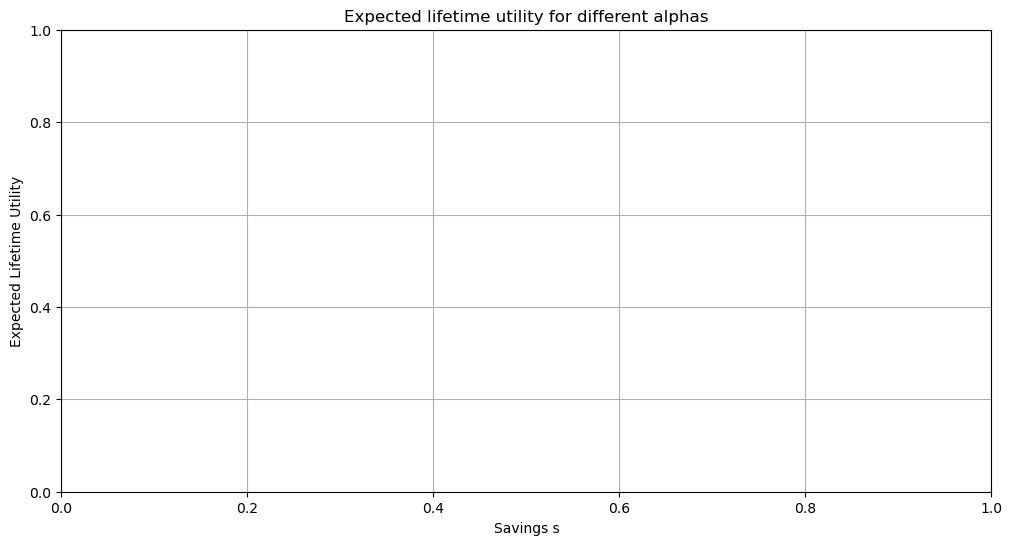

In [11]:
# Initialize parameters s and alpha
alphas = np.array((0, .5, 1))
s = np.linspace(.1, w - .1, 200)

# Initialize plot
plt.figure(figsize=(12,6))
plt.title('Expected lifetime utility for different alphas')
plt.xlabel('Savings s')
plt.ylabel('Expected Lifetime Utility')
plt.xlim((0,1))
plt.grid()

# Loop over alphas to plot
for a in alphas:
    eu_life = expected_util(s=s, alpha=a)
    plt.plot(s, eu_life.flatten(), label=fr'$\alpha$ = {a}')

_ = plt.legend()

In [12]:
def find_optimum(beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Find the optimal savings level and risky share to maximize expected utility
    '''
    # Initialize s and alpha as linear spaces
    s = np.linspace(10**-6, w - 10**-6, 1_000)
    alpha = np.linspace(0, 1, 1_000)

    # Calculate expected lifetime utility for all combinations
    eu_life = expected_util(s, alpha)

    # Identify index and value of max expected utility, and corresponding optimal choices of s and alpha
    imax = np.argmax(eu_life)
    s_opt = s[imax]
    a_opt = alpha[imax]
    U_max = eu_life[imax]

    return s_opt, a_opt, U_max

In [13]:
# Data type?
find_optimum()

ValueError: operands could not be broadcast together with shapes (3,) (1000,1000) 

In [319]:
s_opt, a_opt, U_max = find_optimum()
print(f'Optimal saving: {s_opt:.3f}, Optimal alpha: {a_opt:.3f}, Max Utility: {U_max:.3f}')

Optimal saving: 0.485, Optimal alpha: 0.485, Max Utility: -0.253


### Task 7

In [326]:
gammas = np.linspace(1, 10, 101)

share_opt = np.empty_like(gammas)

for i, gamma in enumerate(gammas):
    s_opt, a_opt, U_max = find_optimum()
    share_opt[i] += a_opt

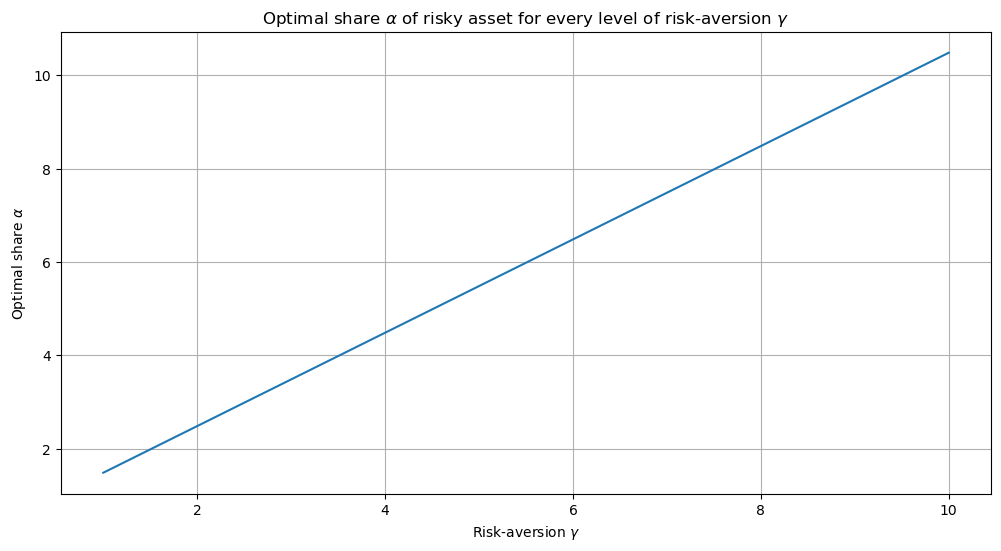

In [329]:
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk-aversion $\gamma$')
plt.xlabel(r'Risk-aversion $\gamma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

_ = plt.plot(gammas, share_opt)

...

### Task 8

In [331]:
gamma = 4
sigmas = np.linspace(.01, .5, 101)

share_opt = np.empty_like(sigmas)

for i, gamma in enumerate(sigmas):
    s_opt, a_opt, U_max = find_optimum()
    share_opt[i] += a_opt

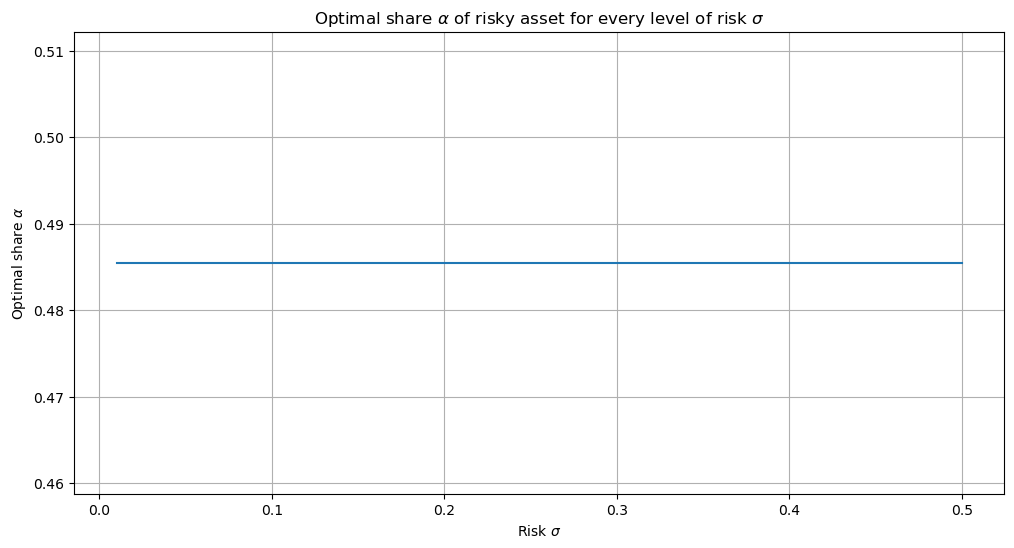

In [332]:
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk $\sigma$')
plt.xlabel(r'Risk $\sigma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

_ = plt.plot(sigmas, share_opt)